# Quran QA Dataset Charts

Notebook untuk analisis dan visualisasi hasil generate serta validasi SI-LAB.

In [6]:
from pathlib import Path
import json
import pandas as pd

ROOT = Path.cwd()
SILAB_DIR = ROOT / "silab"
MODEL_DIR = SILAB_DIR / "model"
JUDGES_DIR = SILAB_DIR / "judges"

MODEL_DIR, JUDGES_DIR

(WindowsPath('d:/Codingan Pribadi/KERJA/VIbe Coding/qurandataset/quranqadataset/silab/silab/model'),
 WindowsPath('d:/Codingan Pribadi/KERJA/VIbe Coding/qurandataset/quranqadataset/silab/silab/judges'))

,dataset,agreement,count,total,percentage
0,MPTP,3/3,2082,2600,80.08
1,MPTP,2/3,376,2600,14.46
2,MPTP,1/3,100,2600,3.85
3,MPTP,0/3,42,2600,1.62
4,SPTP,3/3,2087,2600,80.27
5,SPTP,2/3,362,2600,13.92
6,SPTP,1/3,88,2600,3.38
7,SPTP,0/3,63,2600,2.42


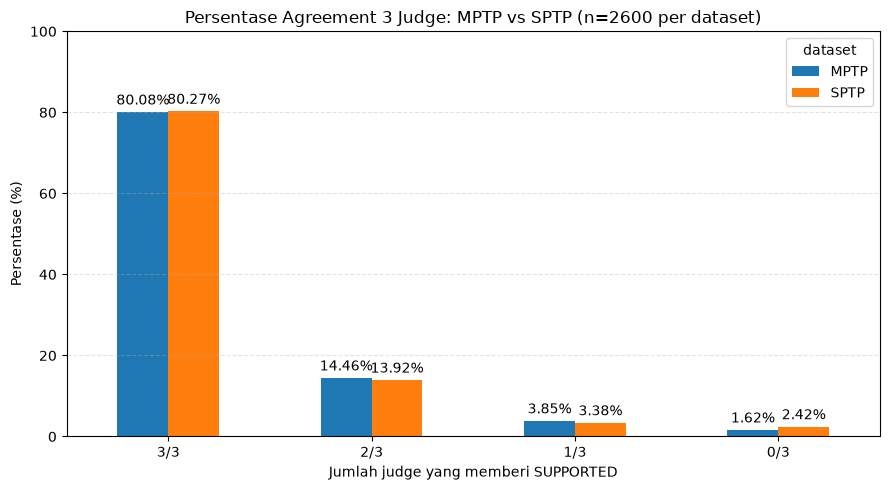

In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
silab_dir = cwd if cwd.name == "silab" else cwd / "silab"
judges_dir = silab_dir / "judges"

log_files = {
    "MPTP": judges_dir / "validation_log_3models_gpt_oss_120b_MPTP_2600.jsonl",
    "SPTP": judges_dir / "validation_log_3models_gpt_oss_120b_SPTP_2600.jsonl",
}

rows = []
for dataset, path in log_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Log file tidak ditemukan: {path}")

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            record = json.loads(line)
            if record.get("event") != "validated":
                continue

            support_count = sum(
                record.get(label) == "SUPPORTED"
                for label in ["A", "B", "C"]
            )
            rows.append({
                "dataset": dataset,
                "support_count": support_count,
                "agreement": f"{support_count}/3",
            })

df = pd.DataFrame(rows)
order = ["3/3", "2/3", "1/3", "0/3"]

summary = (
    df.groupby(["dataset", "agreement"])
      .size()
      .rename("count")
      .reset_index()
)

all_combinations = pd.MultiIndex.from_product(
    [log_files.keys(), order],
    names=["dataset", "agreement"]
).to_frame(index=False)

summary = (
    all_combinations.merge(summary, on=["dataset", "agreement"], how="left")
    .fillna({"count": 0})
)
summary["count"] = summary["count"].astype(int)
summary["total"] = summary.groupby("dataset")["count"].transform("sum")
summary["percentage"] = (summary["count"] / summary["total"] * 100).round(2)

display(summary)

chart_data = summary.pivot(index="agreement", columns="dataset", values="percentage").loc[order]
ax = chart_data.plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_title("Persentase Agreement 3 Judge: MPTP vs SPTP (n=2600 per dataset)")
ax.set_xlabel("Jumlah judge yang memberi SUPPORTED")
ax.set_ylabel("Persentase (%)")
ax.set_ylim(0, max(100, chart_data.max().max() * 1.15))
ax.grid(axis="y", linestyle="--", alpha=0.35)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

,dataset,judge_pair,both_supported,total,percentage
0,MPTP,A-B,2088,2600,80.31
1,MPTP,A-C,2368,2600,91.08
2,MPTP,B-C,2166,2600,83.31
3,SPTP,A-B,2091,2600,80.42
4,SPTP,A-C,2358,2600,90.69
5,SPTP,B-C,2174,2600,83.62


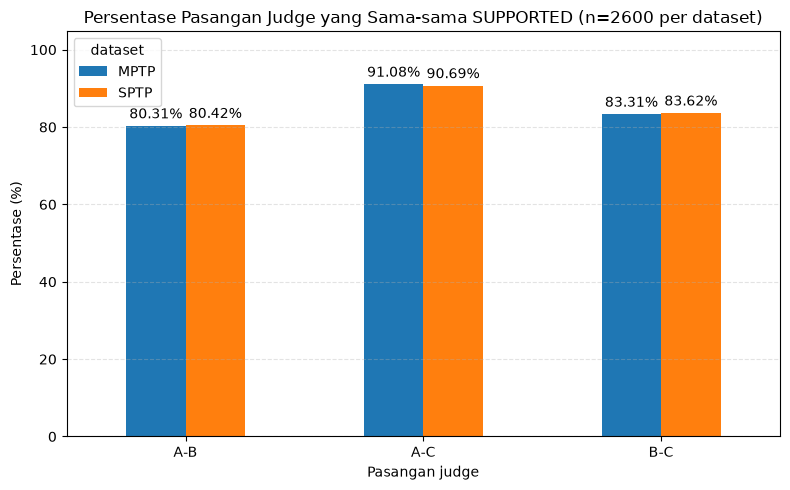

In [9]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
silab_dir = cwd if cwd.name == "silab" else cwd / "silab"
judges_dir = silab_dir / "judges"

log_files = {
    "MPTP": judges_dir / "validation_log_3models_gpt_oss_120b_MPTP_2600.jsonl",
    "SPTP": judges_dir / "validation_log_3models_gpt_oss_120b_SPTP_2600.jsonl",
}

judge_pairs = [("A", "B"), ("A", "C"), ("B", "C")]
rows = []

for dataset, path in log_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Log file tidak ditemukan: {path}")

    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            record = json.loads(line)
            if record.get("event") == "validated":
                records.append(record)

    total = len(records)
    for left, right in judge_pairs:
        both_supported = sum(
            record.get(left) == "SUPPORTED" and record.get(right) == "SUPPORTED"
            for record in records
        )
        rows.append({
            "dataset": dataset,
            "judge_pair": f"{left}-{right}",
            "both_supported": both_supported,
            "total": total,
            "percentage": round(both_supported / total * 100, 2) if total else 0,
        })

pair_summary = pd.DataFrame(rows)
display(pair_summary)

chart_data = pair_summary.pivot(index="judge_pair", columns="dataset", values="percentage").loc[["A-B", "A-C", "B-C"]]
ax = chart_data.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_title("Persentase Pasangan Judge yang Sama-sama SUPPORTED (n=2600 per dataset)")
ax.set_xlabel("Pasangan judge")
ax.set_ylabel("Persentase (%)")
ax.set_ylim(0, max(100, chart_data.max().max() * 1.15))
ax.grid(axis="y", linestyle="--", alpha=0.35)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

In [20]:
from pathlib import Path
import json
import pandas as pd

cwd = Path.cwd()
root = cwd.parent if cwd.name == "silab" else cwd
silab_dir = root / "silab"
judges_dir = silab_dir / "judges"

TAKE_FIRST = 2600
JUDGE_KEYS = ("A", "B", "C")
VALID_VERDICTS = {"SUPPORTED", "NOT_SUPPORTED"}


def extract_verdicts(record):
    return {judge: record.get(judge) for judge in JUDGE_KEYS}


def has_complete_verdicts(record):
    return all(record.get(judge) in VALID_VERDICTS for judge in JUDGE_KEYS)


def load_silab_validated(path, limit):
    records_by_key = {}
    ordered_keys = []

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            record = json.loads(line)
            if record.get("event") != "validated":
                continue
            if not has_complete_verdicts(record):
                continue

            key = (record.get("surah"), record.get("ayat"))
            if None in key or key in records_by_key:
                continue

            records_by_key[key] = extract_verdicts(record)
            ordered_keys.append(key)

            if limit is not None and len(ordered_keys) >= limit:
                break

    return records_by_key, ordered_keys


def load_azure_validated(path):
    records_by_key = {}

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            record = json.loads(line)
            if record.get("event") and record.get("event") != "validated":
                continue
            if not has_complete_verdicts(record):
                continue

            key = (record.get("surah"), record.get("ayat"))
            if None in key or key in records_by_key:
                continue

            records_by_key[key] = extract_verdicts(record)

    return records_by_key


intersection_jobs = {
    "MPTP": {
        "silab_log": judges_dir / "validation_log_3models_gpt_oss_120b_MPTP.jsonl",
        "azure_log": root / "validation_log_3models_MPTP.jsonl",
        "output": judges_dir / "validation_log_3models_gpt_oss_120b_MPTP_2600_intersection.jsonl",
    },
    "SPTP": {
        "silab_log": judges_dir / "validation_log_3models_gpt_oss_120b_SPTP.jsonl",
        "azure_log": root / "validation_log_3models_SPTP.jsonl",
        "output": judges_dir / "validation_log_3models_gpt_oss_120b_SPTP_2600_intersection.jsonl",
    },
}

summary_rows = []

for dataset, paths in intersection_jobs.items():
    silab_records, silab_order = load_silab_validated(paths["silab_log"], TAKE_FIRST)
    azure_records = load_azure_validated(paths["azure_log"])
    intersection_keys = [key for key in silab_order if key in azure_records]

    with paths["output"].open("w", encoding="utf-8") as out:
        for surah, ayat in intersection_keys:
            key = (surah, ayat)
            formatted_record = {
                "surah": surah,
                "ayat": ayat,
                "silab": silab_records[key],
                "azure": azure_records[key],
            }
            out.write(json.dumps(formatted_record, ensure_ascii=False) + "\n")

    summary_rows.append({
        "dataset": dataset,
        "silab_sample_validated": len(silab_order),
        "azure_keys": len(azure_records),
        "intersection_count": len(intersection_keys),
        "intersection_percentage": round(len(intersection_keys) / len(silab_order) * 100, 2) if silab_order else 0,
        "output_file": str(paths["output"]),
    })

intersection_summary = pd.DataFrame(summary_rows)
try:
    display(intersection_summary)
except NameError:
    print(intersection_summary.to_string(index=False))


,dataset,silab_sample_validated,azure_keys,intersection_count,intersection_percentage,output_file
0,MPTP,2600,4644,2571,98.88,d:\Codingan Pribadi\KERJA\VIbe Coding\qurandat...
1,SPTP,2600,4675,2564,98.62,d:\Codingan Pribadi\KERJA\VIbe Coding\qurandat...


In [ ]:
from pathlib import Path
import json
import pandas as pd

cwd = Path.cwd()
root = cwd.parent if cwd.name == "silab" else cwd
silab_dir = root / "silab"
judges_dir = silab_dir / "judges"

JUDGE_KEYS = ("A", "B", "C")
MODEL_SLUG = "gpt_oss_120b"


def count_supported(record, source):
    return sum(
        1
        for judge in JUDGE_KEYS
        if record.get(source, {}).get(judge) == "SUPPORTED"
    )


def load_intersection(path):
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records


def load_gold_by_verse(path):
    gold_items = json.loads(path.read_text(encoding="utf-8"))
    gold_by_key = {}
    duplicate_keys = set()

    for item in gold_items:
        key = (item.get("surah"), item.get("ayat"))
        if None in key:
            continue
        if key in gold_by_key:
            duplicate_keys.add(key)
            continue
        gold_by_key[key] = item

    return gold_items, gold_by_key, duplicate_keys


jobs = {
    "MPTP": {
        "intersection": judges_dir / f"validation_log_3models_{MODEL_SLUG}_MPTP_2600_intersection.jsonl",
        "majority_source": judges_dir / f"gold_majority_supported_{MODEL_SLUG}_MPTP.json",
        "strict_source": judges_dir / f"gold_strict_supported_{MODEL_SLUG}_MPTP.json",
        "majority_output": judges_dir / f"gold_majority_supported_{MODEL_SLUG}_MPTP_silab2_azure2.json",
        "strict_output": judges_dir / f"gold_strict_supported_{MODEL_SLUG}_MPTP_silab3_azure3.json",
    },
    "SPTP": {
        "intersection": judges_dir / f"validation_log_3models_{MODEL_SLUG}_SPTP_2600_intersection.jsonl",
        "majority_source": judges_dir / f"gold_majority_supported_{MODEL_SLUG}_SPTP.json",
        "strict_source": judges_dir / f"gold_strict_supported_{MODEL_SLUG}_SPTP.json",
        "majority_output": judges_dir / f"gold_majority_supported_{MODEL_SLUG}_SPTP_silab2_azure2.json",
        "strict_output": judges_dir / f"gold_strict_supported_{MODEL_SLUG}_SPTP_silab3_azure3.json",
    },
}

summary_rows = []

for dataset, paths in jobs.items():
    intersection_records = load_intersection(paths["intersection"])
    majority_source_items, majority_source_by_key, majority_duplicates = load_gold_by_verse(paths["majority_source"])
    strict_source_items, strict_source_by_key, strict_duplicates = load_gold_by_verse(paths["strict_source"])

    majority_gold = []
    strict_gold = []
    missing_majority_source_keys = []
    missing_strict_source_keys = []
    vote_distribution = {}

    for record in intersection_records:
        key = (record.get("surah"), record.get("ayat"))
        silab_supported = count_supported(record, "silab")
        azure_supported = count_supported(record, "azure")
        bucket = f"silab_{silab_supported}_azure_{azure_supported}"
        vote_distribution[bucket] = vote_distribution.get(bucket, 0) + 1

        if silab_supported >= 2 and azure_supported >= 2:
            gold_item = majority_source_by_key.get(key)
            if gold_item is None:
                missing_majority_source_keys.append(key)
            else:
                majority_gold.append(gold_item)

        if silab_supported == 3 and azure_supported == 3:
            gold_item = strict_source_by_key.get(key)
            if gold_item is None:
                missing_strict_source_keys.append(key)
            else:
                strict_gold.append(gold_item)

    paths["majority_output"].write_text(
        json.dumps(majority_gold, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )
    paths["strict_output"].write_text(
        json.dumps(strict_gold, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )

    summary_rows.append({
        "dataset": dataset,
        "intersection_total": len(intersection_records),
        "majority_source_file": str(paths["majority_source"]),
        "strict_source_file": str(paths["strict_source"]),
        "majority_source_total": len(majority_source_items),
        "strict_source_total": len(strict_source_items),
        "majority_silab_min2_azure_min2": len(majority_gold),
        "strict_silab3_azure3": len(strict_gold),
        "missing_majority_source": len(missing_majority_source_keys),
        "missing_strict_source": len(missing_strict_source_keys),
        "duplicate_majority_source_keys_ignored": len(majority_duplicates),
        "duplicate_strict_source_keys_ignored": len(strict_duplicates),
        "majority_output": str(paths["majority_output"]),
        "strict_output": str(paths["strict_output"]),
        **dict(sorted(vote_distribution.items())),
    })

combined_gold_summary = pd.DataFrame(summary_rows)
try:
    display(combined_gold_summary)
except NameError:
    print(combined_gold_summary.to_string(index=False))
